## create local automata

In [26]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation

def creare_random_connected_graph(n_nodes, n_edges):
    # Generate a random graph
    G = nx.Graph()

    # Add nodes
    G.add_nodes_from(range(n_nodes))

    # Add random edges
    while G.number_of_edges() < n_edges:
        u = random.randint(0, n_nodes-1)
        v = random.randint(0, n_nodes-1)
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)
    # Check if graph is connected
    while not nx.is_connected(G):
        # Add random edges until connected
        # get disconnected node
        disconnected_node = random.choice(list(nx.isolates(G)))
        # get random node
        random_node = random.choice(list(G.nodes()))
        if disconnected_node != random_node and not G.has_edge(disconnected_node, random_node):
            G.add_edge(disconnected_node, random_node)
    return G


colors = [np.random.rand(3,) for _ in range(5)]
graphs = []
pos_list = []
graphs_number = 5
nodes_number = 5
edges_number = 7

for _ in range(graphs_number):
    G = creare_random_connected_graph(nodes_number, edges_number)
    graphs.append(G)
    pos_list.append(nx.spring_layout(G))

In [27]:
def generate_random_conditions(graph, graphs_number, target_automaton, max_edge_conditions):
    nodes_number = len(graph.nodes())
    conditions = {}

    for edge in graph.edges(data=True):
        edge_conditions_number = random.randint(0, max_edge_conditions)
        conditions[(edge[0], edge[1])] = []

        available_automatons = [x for x in range(graphs_number) if x != target_automaton]

        for n in range(edge_conditions_number):
            automaton_index = random.randint(0, len(available_automatons)-1)
            condition = {"automaton": available_automatons[automaton_index], 
                        "state": random.randint(0, nodes_number)}
            available_automatons.remove(available_automatons[automaton_index])

            conditions[(edge[0], edge[1])].append(condition)

    return conditions

## prepare states

In [ ]:
numbers = np.random.randint(0, nodes_number, size=nodes_number)
target_automaton = 0
target_state = 0
max_conditions_per_edge = 3
highlighted_target_states = {}

steps = []
shortest_paths = {}
current_edges = {}
conditions = {}

for i in range(graphs_number):
    target_automaton = i % graphs_number
    target_state = i % graphs_number

    if i == 0:
        hightlighted_target_state = 0
    else:
        hightlighted_target_state = None
        
    if graphs[i].has_edge(numbers[i], target_state):
        current_edge = (numbers[i], target_state)
    else:
        current_edge = None

    shortest_path = nx.shortest_path(graphs[i], source=numbers[i], target=target_state)
    graph_conditions = generate_random_conditions(graphs[i], graphs_number, target_automaton, max_conditions_per_edge)

    highlighted_target_states[target_automaton] = hightlighted_target_state
    shortest_paths[target_automaton] = shortest_path
    conditions[target_automaton] = graph_conditions
    current_edges[target_automaton] = current_edge

for i in range(graphs_number):
    target_automaton = i % graphs_number
    target_state = i % graphs_number

    steps.append({  'goal': {'target_automaton': target_automaton,
                           'target_state': target_state},
                           'local_states': numbers,
                    'visualize':{'current_edges':current_edges,
                           'hightlighted_states': highlighted_target_states,
                           'shortest_paths':shortest_paths,
                           'edge_conditions': conditions}
                           })

print(steps)
print(len(steps))
print(shortest_paths)
print(conditions)

[{'goal': {'target_automaton': 0, 'target_state': 0}, 'local_states': array([4, 2, 4, 4, 1]), 'visualize': {'current_edges': {0: (4, 0), 1: (2, 1), 2: None, 3: None, 4: None}, 'hightlighted_target_states': {0: 0, 1: None, 2: None, 3: None, 4: None}, 'shortest_paths': {0: [4, 0], 1: [2, 1], 2: [4, 1, 2], 3: [4, 1, 3], 4: [1, 3, 4]}, 'edge_conditions': {0: {(0, 3): [], (0, 4): [{'automaton': 4, 'state': 1}], (0, 2): [{'automaton': 4, 'state': 3}], (1, 3): [], (2, 3): [], (2, 4): [{'automaton': 3, 'state': 5}, {'automaton': 2, 'state': 0}], (3, 4): [{'automaton': 2, 'state': 5}, {'automaton': 4, 'state': 0}]}, 1: {(0, 2): [{'automaton': 4, 'state': 3}, {'automaton': 0, 'state': 4}], (0, 4): [{'automaton': 2, 'state': 3}], (0, 3): [{'automaton': 2, 'state': 0}], (1, 2): [{'automaton': 0, 'state': 0}, {'automaton': 3, 'state': 3}], (1, 3): [], (2, 4): [], (2, 3): [{'automaton': 0, 'state': 0}, {'automaton': 2, 'state': 2}]}, 2: {(0, 1): [{'automaton': 1, 'state': 1}, {'automaton': 0, 'state

## Visualizer functions

In [ ]:
# Highlight the current traversing edge
def visualize_current_edge(step, automaton_idx):
        settings = step['visualize']
        current_edge = settings['current_edges'][automaton_idx]

        if current_edge != None:
            graph = settings['graph']
            pos = settings['pos']
            ax = settings['ax']
            color = settings['current_edge_color'] if settings['current_edge_color'] else 'red'
            width = settings['current_edge_width'] if settings['current_edge_width'] else 3
            
            nx.draw_networkx_edges(graph, pos, ax=ax,
                                    edgelist=[(current_edge[0], current_edge[1])],
                                    edge_color=color,
                                    width=width)
            
def highlight_state(step):
    settings = step['visualize']
    pos = settings['pos']
    ax = settings['ax']
    original_target_state = settings['original_target_state']
    node_color = settings['node_color'] if settings['node_color'] else 'red'
    node_size = settings['node_size'] if settings['node_size'] else 600
    nx.draw_networkx_nodes(G, pos, ax=ax,
                        nodelist=[original_target_state],
                        node_color='red',
                        node_size=node_size)
    
def highlight_shortest_path(step):
    
    for n in range(len(steps[i]['shortest_path'])-1):
        nx.draw_networkx_edges(G, pos, ax=ax,
                            edgelist=[(current_state['shortest_path'][n], current_state['shortest_path'][n+1])],
                            edge_color='blue',
                            width=3)

visualize_dict = {'current_edges': visualize_current_edge,
                  'hightlighted_states': highlight_state}

## animate

/home/jan/miniconda3/envs/sos/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


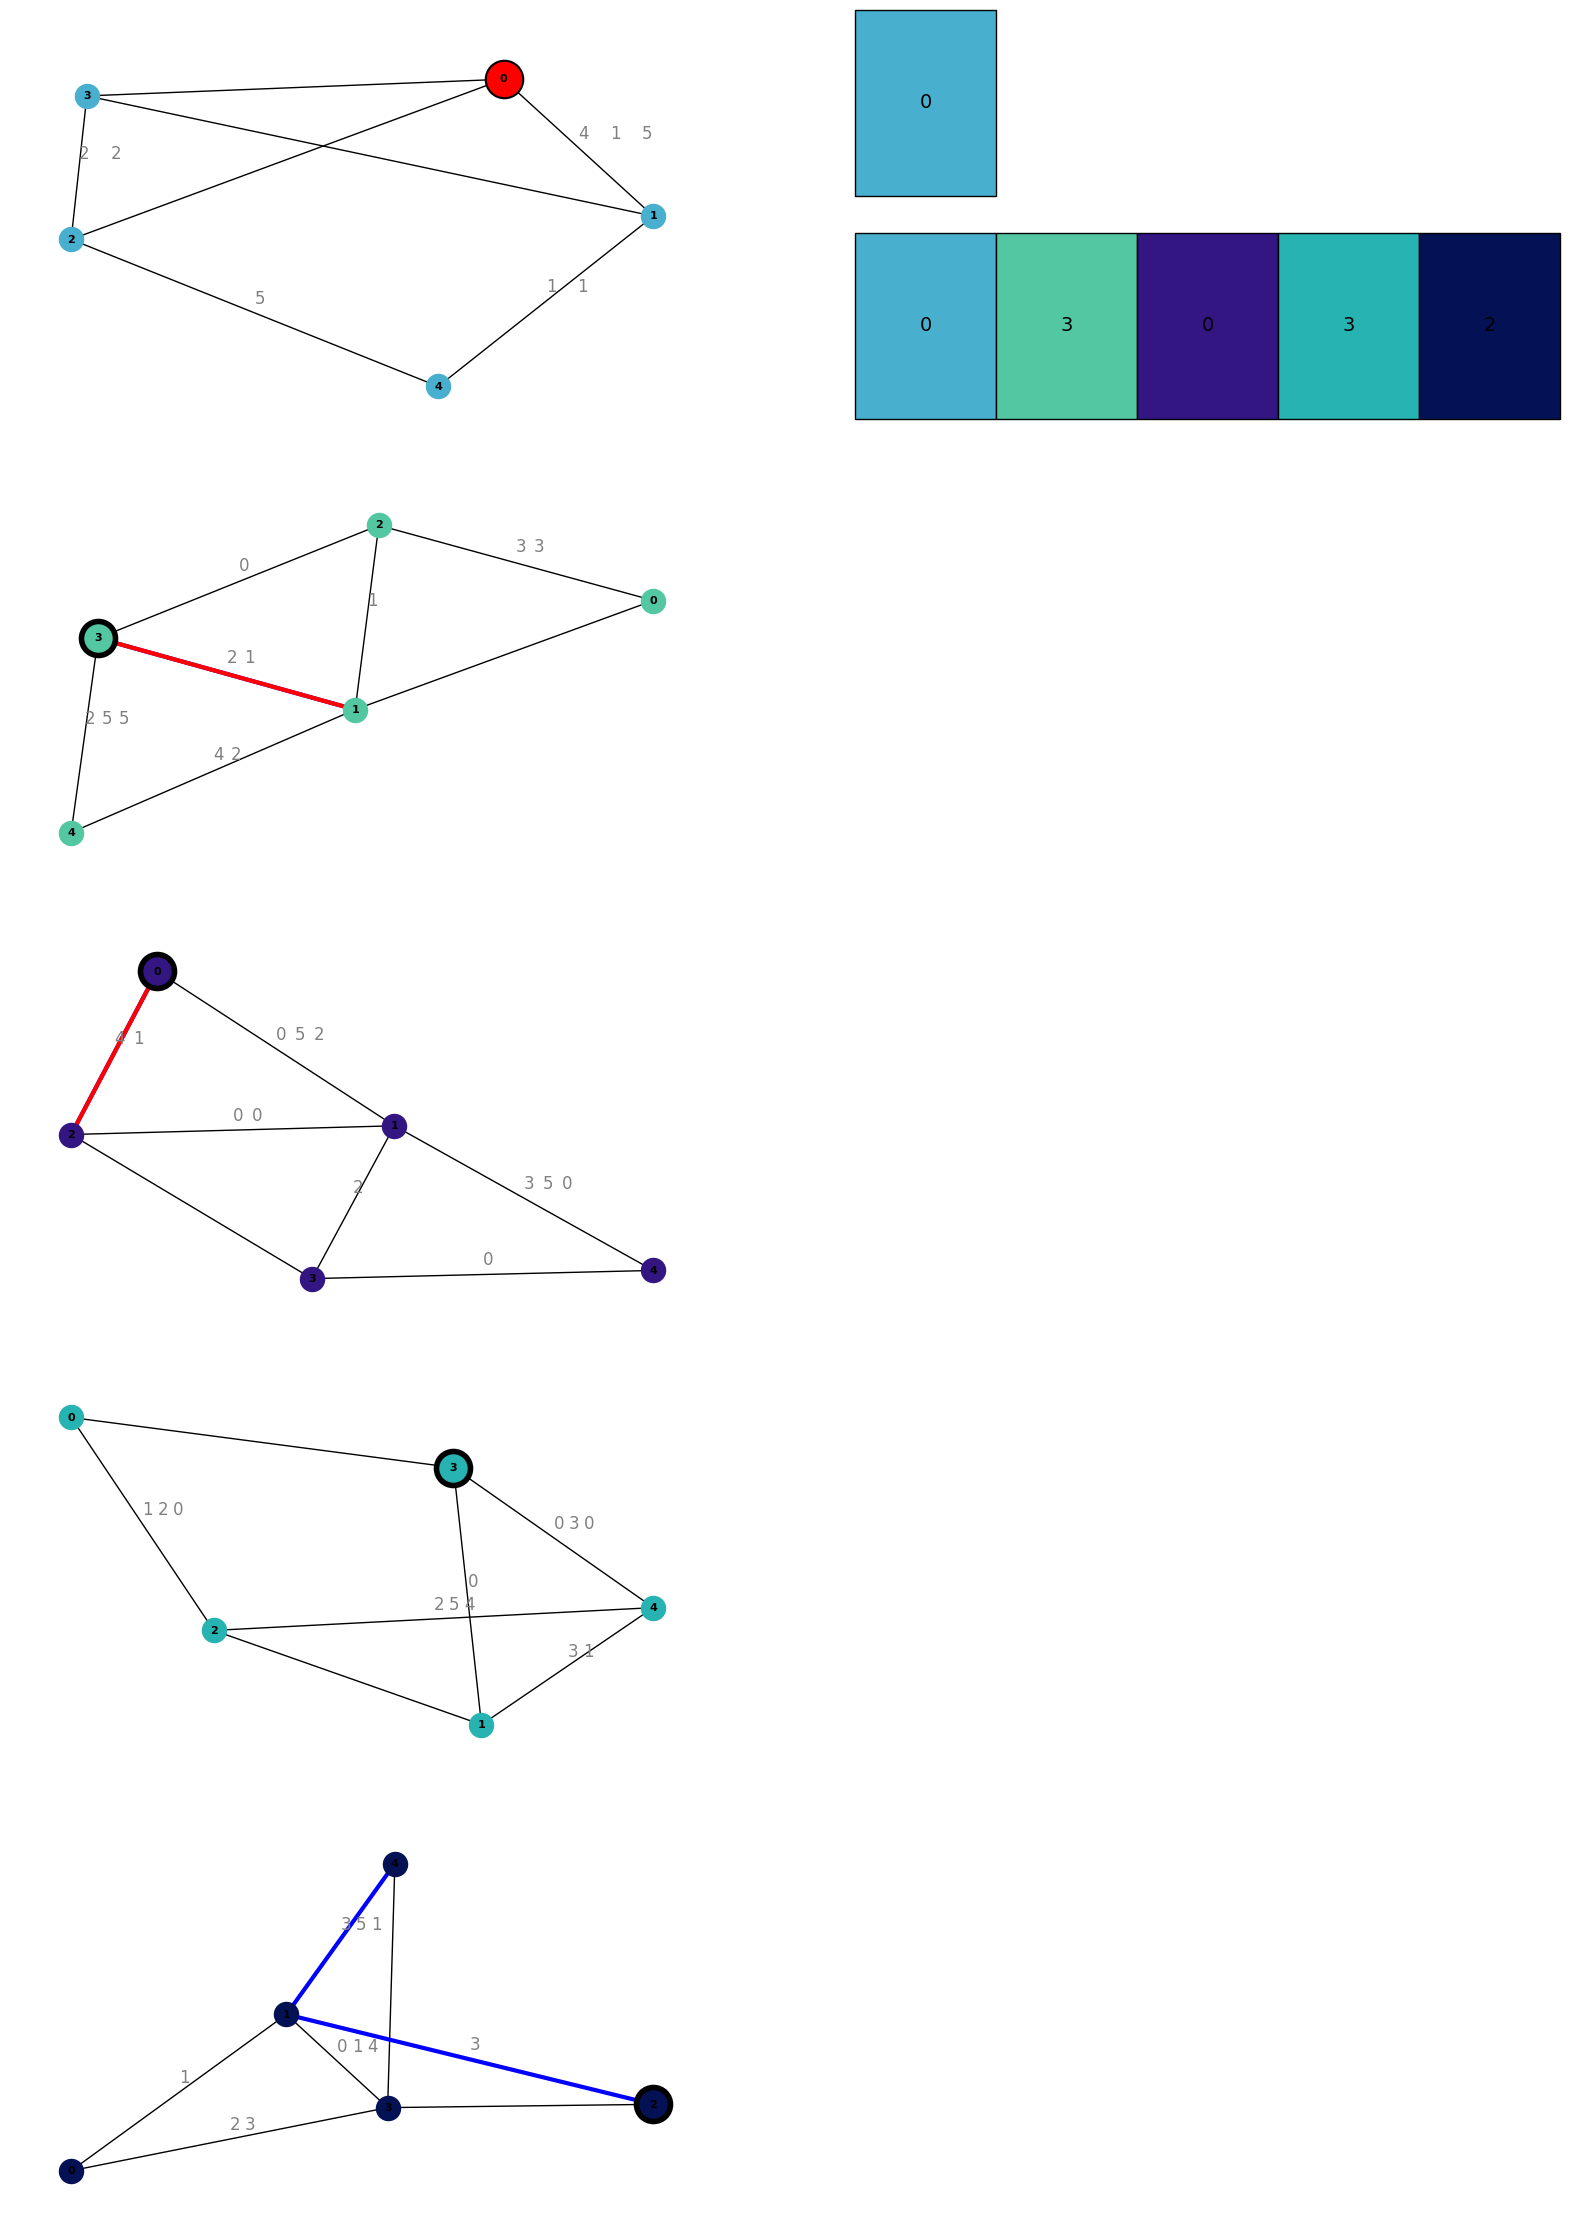

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with custom gridspec
fig = plt.figure(figsize=(20, 28))
gs = plt.GridSpec(graphs_number, 2, figure=fig)

# Function to update the frame
def update(frame, steps):
    state = steps[frame]
    current_goal = state['goal']
    target_state = current_goal['target_state']
    target_automaton = current_goal['target_automaton']

    numbers = state['local_states']

    # Clear the figure
    fig.clear()

    # Create 5 random graphs in the first column
    for i in range(graphs_number):
        local_state = numbers[i]
        current_state = steps[i]
        
        ax = fig.add_subplot(gs[i, 0])
        # Generate random graph
        G = graphs[i]
        
        # Draw the graph
        pos = pos_list[i]
        
        # Draw all nodes
        nx.draw(G, pos, ax=ax, with_labels=True,
                node_color=colors[i], node_size=300,
                font_size=8, font_weight='bold')
        
        # Highlight the node corresponding to local_state with thicker border
        nx.draw_networkx_nodes(G, pos, ax=ax,
                            nodelist=[local_state],
                            node_color=colors[i],
                            node_size=600,
                            edgecolors='black',
                            linewidths=4)
        
        for edge in G.edges(data=True):
            for m, condition in enumerate(state["edge_conditions"][i][(edge[0], edge[1])]):
                edge_pos = pos[edge[0]] + (pos[edge[1]] - pos[edge[0]]) * 0.5
                state_str = 'state'
                plt.text(edge_pos[0]+0.05*m, edge_pos[1]+0.05, f'{condition[state_str]}', color='grey', fontsize=12)
                


        #ax.set_title(f'Random Graph {i+1}')

    # Create 1 subplot spanning all rows in second column
    ax = fig.add_subplot(gs[:1, 1])

    ax.clear()
    ax.axis('off')
    # Create vector of 5 random numbers
    top_row = [str(target_state)]
    top_colors = [colors[target_automaton]]
    # Create sample data for tables
    table1 = ax.table(cellText=[numbers],
                    cellColours=[colors],
                    cellLoc='center',
                    loc='center',
                    bbox=[0, 0, 1, 0.5])

    table2 = ax.table(cellText=[top_row],
                    cellColours=[top_colors],
                    cellLoc='center',
                    loc='center',
                    bbox=[0.2*target_automaton, 0.6, 0.2, 0.5]) # prvni souradnice ovlivnuje umisteni vrchni bunky

    # Style the tables
    table1.set_fontsize(14)
    table2.set_fontsize(14)

# Create animation
anim = animation.FuncAnimation(fig, update, frames=5,
                               fargs=(steps,) ,
                             interval=1000, repeat=True)
anim.save('search_animation.gif', writer='pillow')



In [59]:
states

[{'goal': {'target_automaton': 0, 'target_state': 0},
  'local_states': array([0, 3, 0, 3, 2]),
  'shortest_path': [0],
  'edge_conditions': {0: {(0, 2): [],
    (0, 1): [{'automaton': 4, 'state': 4},
     {'automaton': 2, 'state': 1},
     {'automaton': 1, 'state': 5}],
    (0, 3): [],
    (1, 4): [{'automaton': 2, 'state': 1}, {'automaton': 1, 'state': 1}],
    (1, 3): [],
    (2, 3): [{'automaton': 3, 'state': 2}, {'automaton': 2, 'state': 2}],
    (2, 4): [{'automaton': 1, 'state': 5}]},
   1: {(0, 1): [],
    (0, 2): [{'automaton': 2, 'state': 3}, {'automaton': 3, 'state': 3}],
    (1, 4): [{'automaton': 0, 'state': 4}, {'automaton': 4, 'state': 2}],
    (1, 2): [{'automaton': 0, 'state': 1}],
    (1, 3): [{'automaton': 2, 'state': 2}, {'automaton': 4, 'state': 1}],
    (2, 3): [{'automaton': 0, 'state': 0}],
    (3, 4): [{'automaton': 2, 'state': 2},
     {'automaton': 4, 'state': 5},
     {'automaton': 0, 'state': 5}]},
   2: {(0, 2): [{'automaton': 4, 'state': 4}, {'automaton':

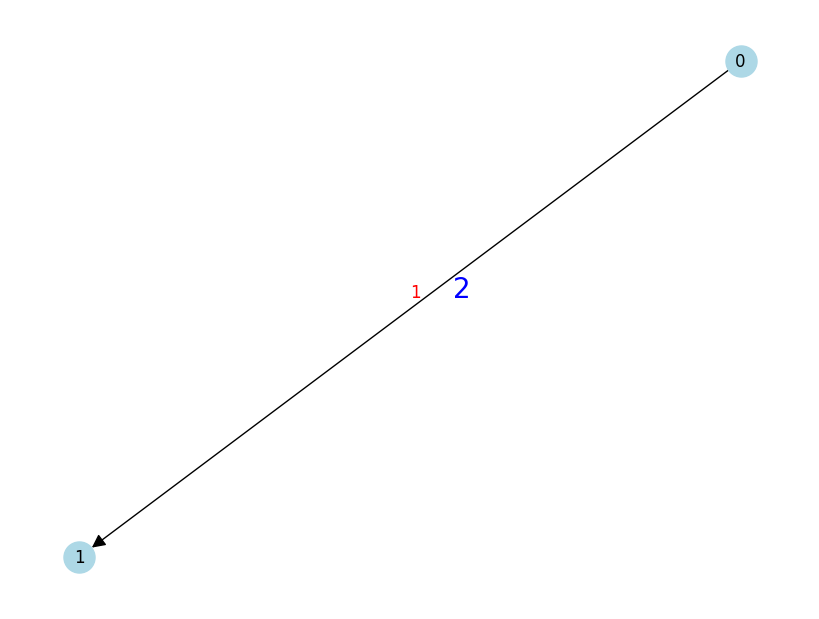

In [24]:
# Create a new figure
plt.figure(figsize=(8,6))

# Create a directed graph
G = nx.DiGraph()
G.add_edge(0, 1)

# Set up the layout
pos = nx.spring_layout(G)

# Draw the graph
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, arrowsize=20)

# Create edge labels with different colors
edge_labels = {(0,1): ''}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Add the colored numbers separately
# Get the edge midpoint position
edge_pos = pos[0] + (pos[1] - pos[0]) * 0.5
plt.text(edge_pos[0], edge_pos[1]+0.05, '1', color='red', fontsize=12)
plt.text(edge_pos[0]+0.05, edge_pos[1]+0.05, '2', color='blue', fontsize=20)

plt.axis('off')
plt.show()
